In [308]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile
from statsmodels.tsa.stattools import acf
from scipy.signal.windows import triang
import pyreaper
import math

In [309]:
def plot_signal(signal: np.ndarray, fs: int = 44100, duration: float = 5):
    """ Визуализация сигнала """
    plt.figure(figsize=(10, 4))
    time_counts = np.linspace(0, duration, int(fs * duration))
    plt.plot(time_counts, signal[:len(time_counts)])
    plt.xlabel("Время (с)")
    plt.ylabel("Амплитуда")
    plt.title("Входной звуковой сигнал")
    plt.grid()
    plt.show()

In [310]:
def plot_characteristics(x: np.ndarray, title: str, x_label: str, y_label: str):
    """ Визуализация графиков """
    plt.figure(figsize=(10, 4))
    plt.plot(range(len(x)), x)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid()
    plt.show()

In [311]:
def my_acf(x: np.ndarray, m: int):
    """ Реализация автокорреляционной функции """
    N = len(x)
    avg_x = np.mean(x)
    #x[:N-m] - первые N-m элементы сигнала
    #x[m:] - сдвигаем каждый элемент на m
    return np.sum((x[:N-m] - avg_x) * (x[m:] - avg_x)) / (N - m)

In [312]:
def extremum_AKF(x: np.ndarray):
    """ Поиск экстремумов АКФ """
    return [(i, x[i]) for i in range(1, len(x) - 1) if x[i - 1] < x[i] and x[i] > x[i + 1]]


In [313]:
def period_AKF(maximum):
    """ Определение периода основного тона"""
    if len(maximum) > 1:
        print(maximum[1][0],  )
        print(maximum[1][1] )
        return maximum[1][0]  
    return maximum[0][0]  

In [314]:
    
def my_exp(fs, f, N):
    """ Генерирует комплексную экспоненциальную функцию для заданной частоты """
    time_indices = np.arange(N)  
    exponent = -2j * math.pi * f / fs  
    return np.exp(time_indices * exponent)  

def my_dtft(x, fs, freqs):
    """ Реализует дискретное преобразование Фурье (ДВПФ) для одной или нескольких частот """
    signal_length = len(x)  

    spectrum = [abs(np.dot(x, my_exp(fs, f, signal_length))) for f in freqs]  
    return spectrum  


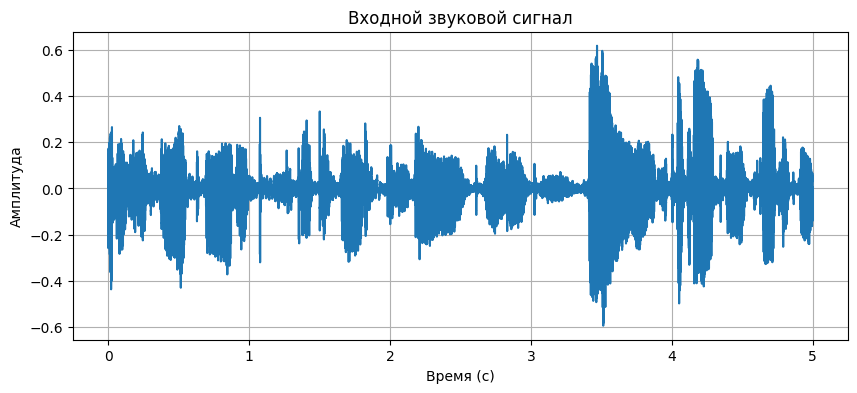

In [315]:
# Загрузка и нормализация входного сигнала
fs, x = wavfile.read('lab2.wav')
if x.ndim == 2:
    x = x[:,0]
    
x = x[fs:]  # Удаление 1 секунды молчания
x = x.astype(np.float32) / max(abs(x.min()), abs(x.max()))
t = np.linspace(0, (len(x) - 1) / fs, len(x))
# Визуализация сигнала
plot_signal(x, fs)

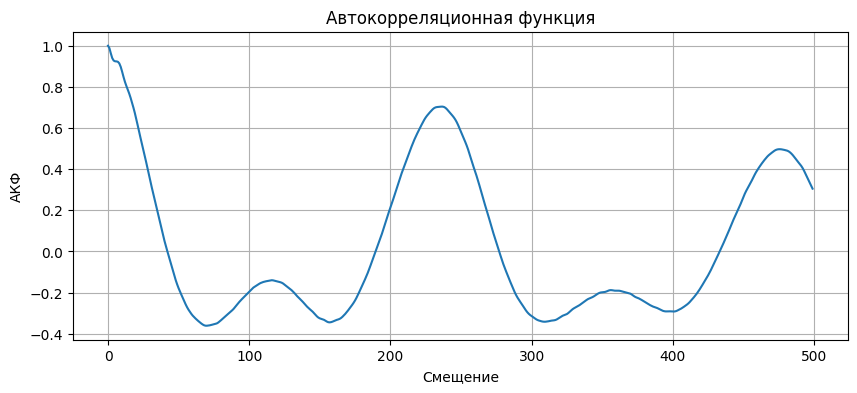

In [316]:
# Вычисление и построение АКФ
AKF = np.array([my_acf(x[:fs], m) for m in range(500)])
AKF /= max(AKF)
plot_characteristics(AKF, "Автокорреляционная функция", "Смещение", "АКФ")


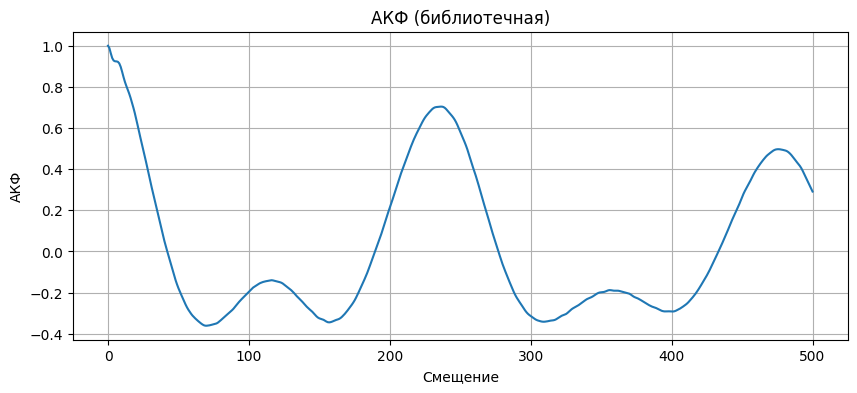

In [317]:
akf_lib = acf(x[:fs], adjusted=True, nlags=500)
plot_characteristics(akf_lib, "АКФ (библиотечная)", "Смещение", "АКФ")


In [318]:
# Оценка периода основного тона
extrema = extremum_AKF(akf_lib)

m_max = period_AKF(extrema)

f_acf = 1 / (m_max * (1 / fs))

print(f"Оценка основной частоты (АКФ): {f_acf:.2f} Гц")

236
0.7039637089642845
Оценка основной частоты (АКФ): 203.39 Гц


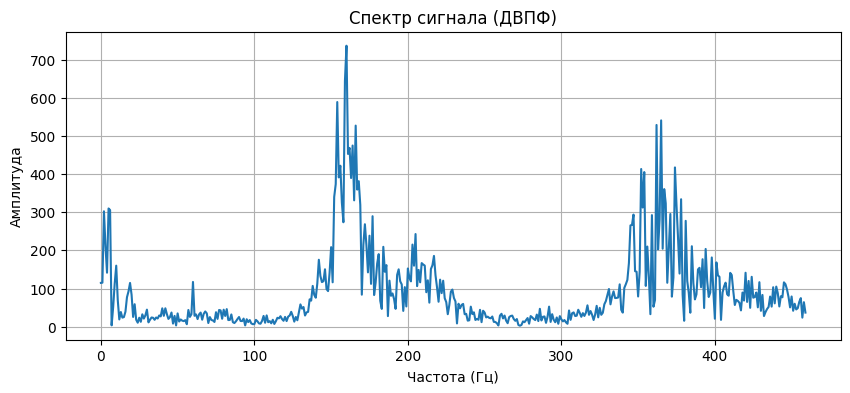

Оценка основной частоты (ДВПФ): 200.00 Гц


In [319]:
# Оценка частоты с помощью ДВПФ
freqs = np.arange(40, 500, 1)
spectrum = my_dtft(x[:fs], fs, freqs)
plot_characteristics(spectrum, "Спектр сигнала (ДВПФ)", "Частота (Гц)", "Амплитуда")

f_dtft = freqs[np.argmax(spectrum)]
print(f"Оценка основной частоты (ДВПФ): {f_dtft:.2f} Гц")


Residual symmetry: P:1976.474731  N:2510.493164  MEAN:-0.020225
Оценка основной частоты (Google REAPER): 233.83 Гц


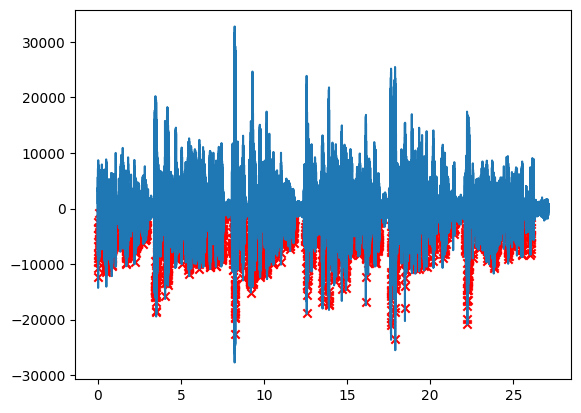

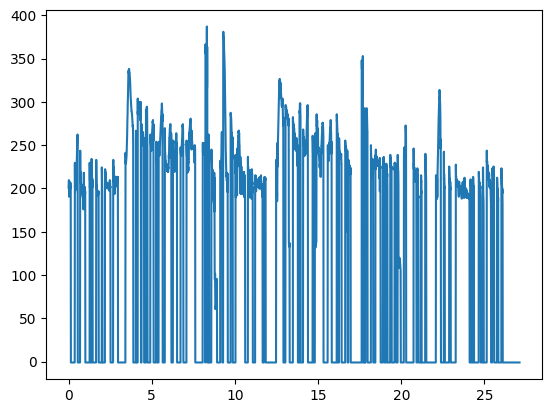

In [320]:
# Оценка частоты с помощью Google REAPER
x_int16 = (x * 32767).astype(np.int16)
pm_times, pm, f_times, f_reaper, _ = pyreaper.reaper(x_int16, fs)
f_reaper_mean = np.mean(f_reaper[f_reaper != -1])

print(f"Оценка основной частоты (Google REAPER): {f_reaper_mean:.2f} Гц")
plt.figure('[Reaper] Pitch Marks')
plt.plot(t, x_int16)
plt.scatter(pm_times[pm == 1], x_int16[(pm_times * fs).astype(int)][pm == 1], marker='x', color='red')
plt.figure('[Reaper] Fundamental Frequency')
plt.plot(f_times, f_reaper)
plt.show()

In [321]:
def my_psola(x: np.ndarray, fs: int, k: float):
    """Изменение высоты тона методом PSOLA"""
    x_int16 = (x * 32767).astype(np.int16)
    pm_times, pm, _, _, _ = pyreaper.reaper(x_int16, fs)

    peaks = pm_times[pm == 1]
    T = np.diff(peaks) * fs
    res_length = int(k * len(x))
    res = np.zeros(res_length, dtype=np.float32)

    shift = 0 

    for i in range(len(T)):
        tpm1 = int(peaks[i] * fs - k * T[i])
        tmp2 = int(peaks[i] * fs + k * T[i])

        if tpm1 < 0 or tmp2 >= len(x):
            continue 

        between = x[tpm1:tmp2]
        window = triang(len(between))
        res[shift:shift + len(between)] += between * window

        shift += int(k * T[i])

    return res / np.max(np.abs(res))



In [307]:
x_psola = my_psola(x, fs, k=1.3)
wavfile.write("lab2_psola.wav", fs, x_psola)

Residual symmetry: P:1976.474731  N:2510.493164  MEAN:-0.020225
